# Numérisation 

In [7]:
# import
import matplotlib.pyplot as plt; from scipy.io import wavfile
%run ./init.py

## Échantillonnage

Enregistrer avec un microphone, c'est comme filmer avec une caméra: on échantillonne = on mesure une valeur toutes les 1/fs secondes

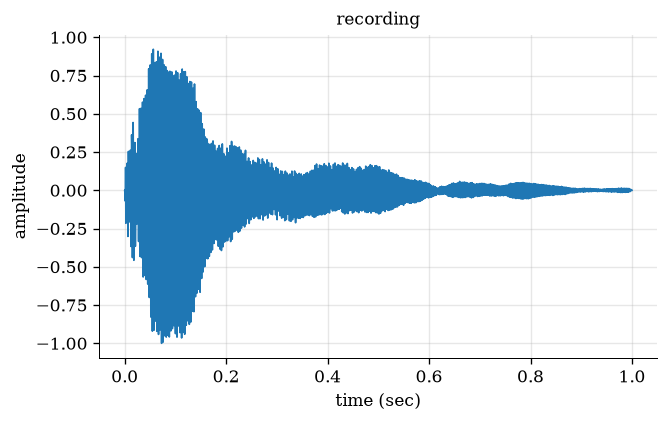

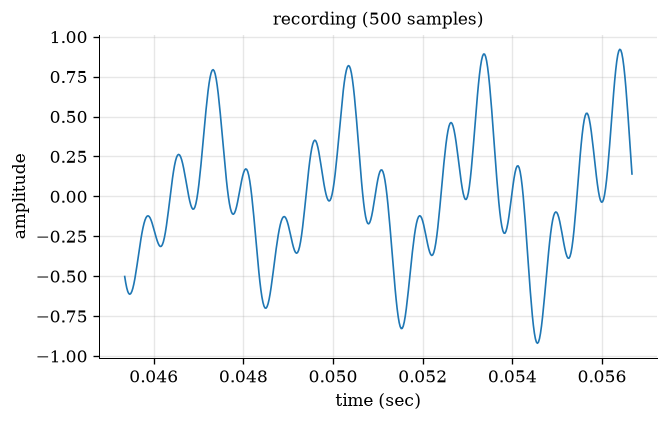

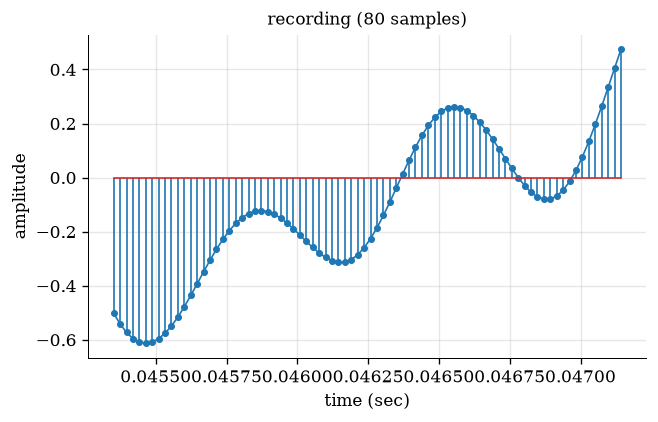

In [8]:
# read file
audio, fs = wavread('assets/steeldrum.wav')

# play sound
playsound(audio, fs)

# plot audio
t = np.arange(0, len(audio)) / fs
plt.plot(t, audio); plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.title('recording'); plt.show()
selvect = np.arange(2000, 2500)
plt.plot(t[selvect], audio[selvect]); plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.title(f'recording ({len(selvect)} samples)'); plt.show()
selvect = np.arange(2000, 2080)
plt.plot(t[selvect], audio[selvect], 'o-'); plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.title(f'recording ({len(selvect)} samples)'); 
plt.stem(t[selvect], audio[selvect]); plt.show()

- Filmer une roue de voiture (phénomène périodique) avec trop peu d'images par secondes -> **aliasing**. 
- Enregistrer un son aigu à une fréquence d'échantillonnage trop basse -> **aliasing**.

- Vous (et votre ordinateur) aurez du mal à "deviner" la sinusoïde ci-dessous si vous réduisez la fréquence d'échantillonnage (`fs`)
- Théorème de **Shannon**: f_max < fs/2 (sinon aliasing)

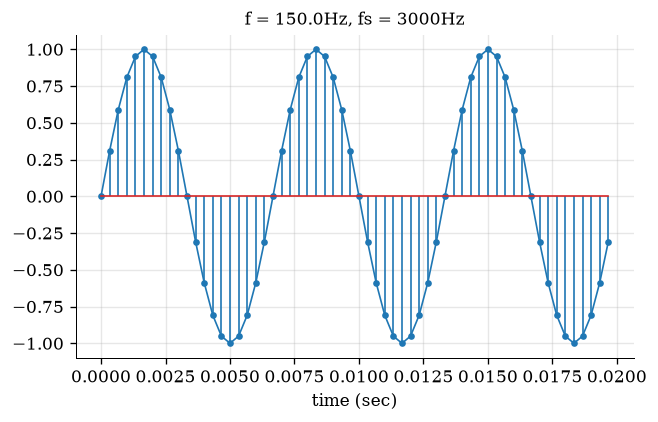

In [13]:
# init locals
fs = 3000 # don't go too low, computer won't be able to play it
freq = 0.05 * fs

# import
import math

# generate sine wave
duration_in_sec = 1
t = np.arange(0, duration_in_sec, 1/fs)
audio = np.sin(2*math.pi*freq*t)

# play audio
playsound(audio, fs)

# plot audio
selvect = np.arange(0, int(3 * fs/freq))
plt.plot(t[selvect], audio[selvect]); plt.xlabel('time (sec)'); plt.title(f'f = {freq}Hz, fs = {fs}Hz')
plt.stem(t[selvect], audio[selvect]);
plt.show()

## Quantification

Pour enregistrer une image, on doit décider du nombre de bits utilisés pour en encoder les couleurs. Pour enregistrer un son, on doit décider du nombre de bits utilisés pour encoder ses échantillons.

Plus on utilise de bits, plus on a de précision. 8 bits nous donne par exemple 2^8 = 256 valeurs potentielles. Ces valeurs seront distribuées entre les valeurs min et max **annoncées** (pas réelles) du signal (typiquement entre -1 et 1 pour un signal audio). On perd par conséquence en précision lors de la numérisation si le signal est de faible amplitude.

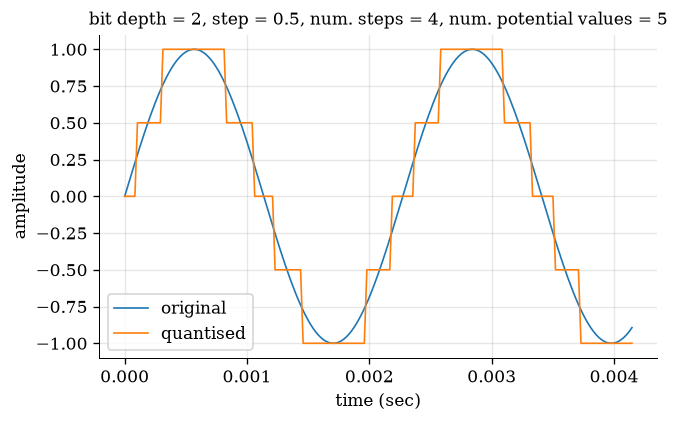

In [10]:
# init locals
bit_depth = 2
max_val = 1; min_val = -1
audio_gain = 1

# create signal
fs = 48000; audio, t = get_sine(440, sampling_rate = fs, duration_in_sec = 1)

# emulate microphone gain
audio *= audio_gain

# numerisation = clip
audio_out = audio.copy()
audio_out[audio_out < min_val] = min_val
audio_out[audio_out > max_val] = max_val

# numerisation = quantisation
q = (max_val - min_val) / 2**bit_depth
audio_out -= min_val
audio_out = np.round(audio_out / q) * q
audio_out += min_val
# summed_error = np.sum(np.abs(audio - audio_out)) / len(audio)

# play
playsound(audio, fs)

# plot
selvect = np.arange(0, 200)
plt.plot(t[selvect], audio[selvect], label = 'original');
plt.plot(t[selvect], audio_out[selvect], label = 'quantised');
plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.ylim([min_val-0.1, max_val+0.1]); plt.legend();
plt.title(f'bit depth = {bit_depth}, step = {q}, num. steps = {2**bit_depth}, num. potential values = {2**bit_depth + 1}')
plt.show()

# play
playsound(audio_out, fs)

## Compression

Non traité ici, sujet important, lire e.g. https://www.onnumerise.com/extras/les-formats-de-compression-audio

## Créer un signal audio numérique

Objectif : créer un ton pur / sinus à f = 100Hz de 1 seconde échantillonné à fs. 
1) Créer le vecteur de temps $t = [1, 2, 3, ..., n\_sample]/fs$

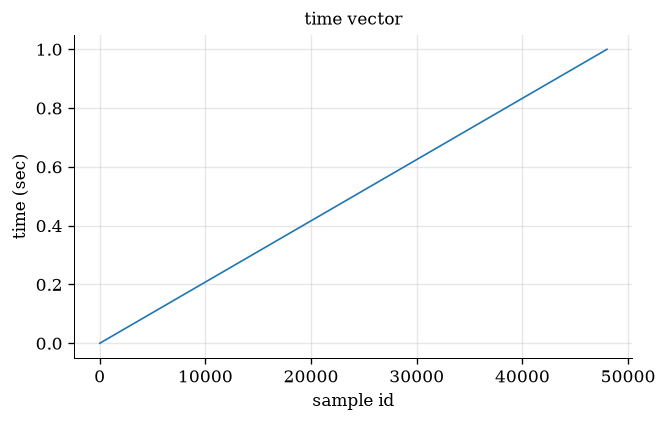

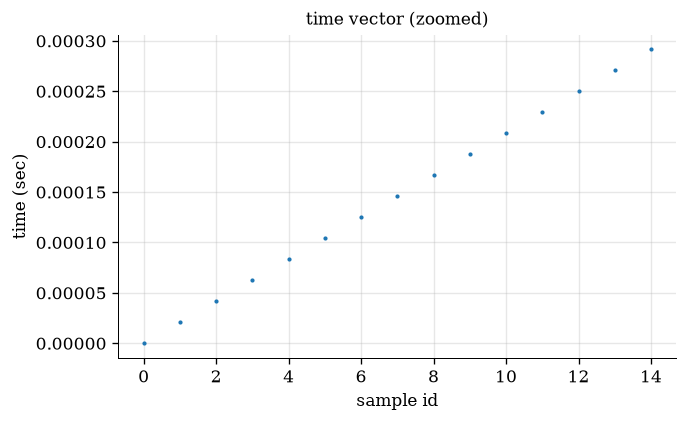

In [11]:
# create time vector
duration_in_sec = 1
n_sample = fs * duration_in_sec
t = np.arange(0, n_sample) / fs

# plot
plt.plot(t)
plt.xlabel('sample id'); plt.ylabel('time (sec)'); plt.title('time vector'); plt.show()

# plot zoom
selvect = np.arange(15)
plt.plot(t[selvect], '.')
plt.xlabel('sample id'); plt.ylabel('time (sec)'); plt.title('time vector (zoomed)'); plt.show()

2) créer un sinus $x(t) = sin(2 \pi * f * t)$

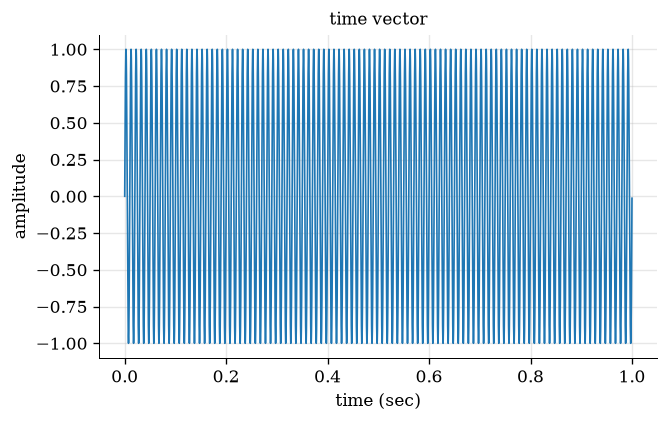

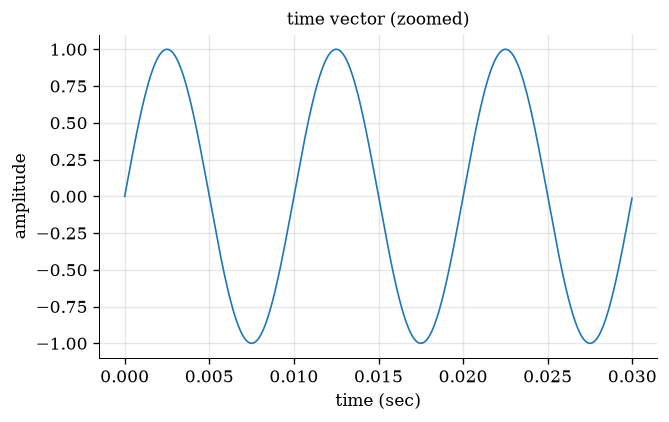

In [12]:
# create signal
f = 100
x = np.sin(2*math.pi*f*t)

# play
playsound(x, fs)

# plot
plt.plot(t, x)
plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.title('time vector'); plt.show()

# plot zoom
selvect = np.arange(3*int(fs/f))
plt.plot(t[selvect], x[selvect])
plt.xlabel('time (sec)'); plt.ylabel('amplitude'); plt.title('time vector (zoomed)'); plt.show()